# ResNet-34 实现 CIFAR-10 图像分类

本 Notebook 使用 PyTorch 从零实现 **ResNet-34** 网络，并在 **CIFAR-10** 数据集上进行图像分类训练与评估。

## 内容概览

| 章节 | 内容 |
|------|------|
| 一、环境配置 | 导入库、检测设备 |
| 二、数据准备 | 数据集解析、Dataset、DataLoader |
| 三、定义模型 | 残差块、残差块组、ResNet-34 主网络 |
| 四、模型训练 | 损失函数、优化器、训练循环、回调函数 |
| 五、模型评估 | 加载最优模型、验证集评估 |
| 六、预测与提交 | 测试集推理、生成 submission.csv |

## 一、环境配置与依赖导入

导入本项目所需的所有 Python 库，并检测当前计算设备（CPU/GPU）。

In [35]:
import matplotlib as mpl               # 导入 matplotlib，Python 最流行的绘图库
import matplotlib.pyplot as plt        # 导入 pyplot 子模块，提供 MATLAB 风格的绘图接口
%matplotlib inline                     
# Jupyter Magic 命令：将图表内嵌显示在 notebook 中
import numpy as np                     # 导入 numpy，Python 科学计算核心库，支持多维数组运算
import sklearn                         # 导入 scikit-learn，提供机器学习算法（如 accuracy_score）
import pandas as pd                    # 导入 pandas，用于数据处理和 DataFrame 操作
import os                              # 导入 os，用于文件/目录操作（如 os.path.exists）
import sys                             # 导入 sys，用于获取 Python 系统信息（如版本号）
import time                            # 导入 time，用于计时
from tqdm import tqdm             # 导入 tqdm，自动选择合适的进度条类型（notebook/命令行）
import torch                           # 导入 PyTorch 深度学习框架主模块
import torch.nn as nn                  # 导入神经网络模块（包含 Linear、Conv2d、BatchNorm2d 等）
import torch.nn.functional as F        # 导入神经网络函数模块（包含 relu、softmax 等无参数函数）

print(sys.version_info)  # 打印 Python 解释器版本信息，格式为 sys.version_info 对象
for module in mpl, np, pd, sklearn, torch:  # 遍历各主要库，打印库名称和版本号，方便排查版本兼容问题
    print(module.__name__, module.__version__)  # 打印变量到控制台，便于调试与验证

# 检测是否有可用的 NVIDIA GPU（CUDA），有则使用第 0 块 GPU，否则退回到 CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")  # 检测是否有可用的 NVIDIA GPU（CUDA），有则使用第 0 块 GPU，否则退回到 CPU；torch.cuda.is_available() 返回 bool，表示当前环境是否支持 CUDA
print(device)   # 打印当前计算设备，如 "cuda:0" 或 "cpu"

seed = 42       # 设置全局随机种子，保证实验结果可复现（后续可传入 torch.manual_seed 等）



sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、数据准备

数据集来源：[Kaggle CIFAR-10 竞赛](https://www.kaggle.com/competitions/cifar-10/data)

```shell                                   
cifar-10
├── sampleSubmission.csv   # 测试集提交模板（含占位标签）
├── test                   # 测试集图片文件夹（300000 张）
├── train                  # 训练集图片文件夹（50000 张）
└── trainLabels.csv        # 训练集标签文件（id, label）
```

### 2.1 解析标签文件与数据路径

读取 CSV 标签文件，将图片 ID 与类别标签配对，构建 `(图片路径, 类别名称)` 元组列表。

In [36]:
from pathlib import Path    # 导入 pathlib.Path，提供面向对象的文件路径操作，跨平台兼容

DATA_DIR = Path("data/cifar-10")  # 数据集根目录，所有数据文件均存放在此目录下

train_lables_file = DATA_DIR / "trainLabels.csv"  # 训练集标签 CSV 文件路径（格式：id,label）
test_csv_file = DATA_DIR / "sampleSubmission.csv"  # 测试集样本提交文件路径（含图片 id 及占位标签）
train_folder = DATA_DIR / "train"  # 训练集图片所在文件夹
test_folder = DATA_DIR / "test"  # 测试集图片所在文件夹

class_names = [  # CIFAR-10 数据集的 10 个类别名称列表（英文标签）
    'airplane',    # 类别 0：飞机
    'automobile',  # 类别 1：汽车
    'bird',        # 类别 2：鸟
    'cat',         # 类别 3：猫
    'deer',        # 类别 4：鹿
    'dog',         # 类别 5：狗
    'frog',        # 类别 6：青蛙
    'horse',       # 类别 7：马
    'ship',        # 类别 8：船
    'truck',       # 类别 9：卡车
]  # 列表定义结束

def parse_csv_file(filepath, folder):  # 定义函数 parse_csv_file，实现数据处理或训练评估流程
    """
    解析 CSV 标签文件，将图片文件名与类别标签配对，构建数据列表。

    参数:
        filepath (str 或 Path): CSV 文件的完整路径，
                                文件格式为两列：id（图片编号）, label（类别字符串）
        folder (str 或 Path):   图片文件夹的完整路径，
                                函数将在此目录下查找对应编号的图片文件

    返回:
        list: 元素为 (图片完整路径 Path, 类别标签字符串) 的元组列表
              例如：[(Path('D:/cifar-10/train/1.png'), 'frog'), ...]
    """
    results = []    # 初始化结果列表，用于存放 (路径, 标签) 元组
    with open(filepath, 'r') as f:  # 以只读模式打开 CSV 文件
        # f.readlines() 返回包含所有行的列表（含换行符）
        lines = f.readlines()[1:]  # f.readlines() 返回包含所有行的列表（含换行符）；[1:] 切片跳过首行（表头行，如 "id,label"），从实际数据行开始
    for line in lines:    # 依次遍历每一条数据行
        image_id, label_str = line.strip('\n').split(',')  # strip('\n') 去除行尾换行符，split(',') 按逗号分割得到 [图片id, 标签字符串]
        image_full_path = folder / f"{image_id}.png"  # 拼接图片完整路径，如 D:/cifar-10/train/1.png
        results.append((image_full_path, label_str))  # 将 (图片路径, 类别标签) 元组追加到结果列表
    return results    # 返回包含所有 (路径, 标签) 对的列表

train_labels_info = parse_csv_file(train_lables_file, train_folder)  # 解析训练集标签 CSV，得到训练集 (图片路径, 标签) 列表，共 50000 条
test_csv_info = parse_csv_file(test_csv_file, test_folder)  # 解析测试集 CSV，得到测试集 (图片路径, 占位标签) 列表，共 300000 条

import pprint  # 使用 pprint 格式化打印，便于阅读嵌套结构
pprint.pprint(train_labels_info[0:5])   # 打印训练集前 5 条，验证解析结果
pprint.pprint(test_csv_info[0:5])       # 打印测试集前 5 条，验证解析结果
print(len(train_labels_info), len(test_csv_info))  # 分别打印训练集和测试集的样本总数


[(WindowsPath('data/cifar-10/train/1.png'), 'frog'),
 (WindowsPath('data/cifar-10/train/2.png'), 'truck'),
 (WindowsPath('data/cifar-10/train/3.png'), 'truck'),
 (WindowsPath('data/cifar-10/train/4.png'), 'deer'),
 (WindowsPath('data/cifar-10/train/5.png'), 'automobile')]
[(WindowsPath('data/cifar-10/test/1.png'), 'cat'),
 (WindowsPath('data/cifar-10/test/2.png'), 'cat'),
 (WindowsPath('data/cifar-10/test/3.png'), 'cat'),
 (WindowsPath('data/cifar-10/test/4.png'), 'cat'),
 (WindowsPath('data/cifar-10/test/5.png'), 'cat')]
50000 300000


### 2.2 划分训练集与验证集

将 50000 条训练数据中的前 45000 条用于训练，后 5000 条用于验证，并构建 DataFrame。

In [37]:
# 若不划分验证集，可直接使用全部训练数据（此行已注释）
# train_df = pd.DataFrame(train_labels_info)  # 说明性注释

# 将前 45000 条数据用作训练集，构建 DataFrame
train_df = pd.DataFrame(train_labels_info[0:45000])  # 将前 45000 条数据用作训练集，构建 DataFrame；pd.DataFrame 接受列表，将每个元组转为一行

valid_df = pd.DataFrame(train_labels_info[45000:])  # 将后 5000 条数据用作验证集，用于监控训练过程中的泛化性能

test_df = pd.DataFrame(test_csv_info)  # 将全部测试集数据构建为 DataFrame

train_df.columns = ['filepath', 'class']   # 'filepath'：图片路径；'class'：类别标签
valid_df.columns = ['filepath', 'class']   # 验证集同样设置列名
test_df.columns = ['filepath', 'class']    # 测试集同样设置列名

print(train_df.head())   # 训练集前 5 行
print(valid_df.head())   # 验证集前 5 行
print(test_df.head())    # 测试集前 5 行


                    filepath       class
0  data\cifar-10\train\1.png        frog
1  data\cifar-10\train\2.png       truck
2  data\cifar-10\train\3.png       truck
3  data\cifar-10\train\4.png        deer
4  data\cifar-10\train\5.png  automobile
                        filepath       class
0  data\cifar-10\train\45001.png       horse
1  data\cifar-10\train\45002.png  automobile
2  data\cifar-10\train\45003.png        deer
3  data\cifar-10\train\45004.png  automobile
4  data\cifar-10\train\45005.png    airplane
                   filepath class
0  data\cifar-10\test\1.png   cat
1  data\cifar-10\test\2.png   cat
2  data\cifar-10\test\3.png   cat
3  data\cifar-10\test\4.png   cat
4  data\cifar-10\test\5.png   cat


### 2.3 自定义 Dataset 类与图像变换

继承 `torch.utils.data.Dataset` 实现 `Cifar10Dataset`，并定义训练集（含数据增强）和验证集（仅基础预处理）的图像变换流水线。

In [38]:
from PIL import Image                           # 导入 Pillow 的 Image 模块，用于打开和转换图片
from torch.utils.data import Dataset, DataLoader  # Dataset：自定义数据集基类；DataLoader：批量数据加载器
from torchvision import transforms              # 导入 torchvision 的图像变换模块，提供常用图像增强操作


class Cifar10Dataset(Dataset):  # 定义类 Cifar10Dataset，封装网络结构或回调逻辑
    """
    CIFAR-10 自定义数据集类，继承自 torch.utils.data.Dataset。

    功能：
        - 根据 mode（'train'/'eval'/'test'）自动选择对应的 DataFrame
        - 支持自定义图像变换（数据增强）
        - 将类别字符串标签转换为整数索引

    类属性:
        df_map (dict): 将模式字符串映射到对应 DataFrame 的字典
        label_to_idx (dict): 类别名称 -> 整数索引，如 {'airplane': 0, ...}
        idx_to_label (dict): 整数索引 -> 类别名称，如 {0: 'airplane', ...}
    """

    df_map = {  # 类级别属性：将模式字符串映射到对应的 DataFrame（所有实例共享）
        "train": train_df,   # 训练集 DataFrame（45000 条）
        "eval": valid_df,    # 验证集 DataFrame（5000 条）
        "test": test_df      # 测试集 DataFrame
    }  # 字典定义结束

    # 类别名称到整数索引的映射字典（用于将字符串标签转换为模型输入的整数）
    label_to_idx = {label: idx for idx, label in enumerate(class_names)}  # 类别名称到整数索引的映射字典（用于将字符串标签转换为模型输入的整数）；enumerate(class_names) 返回 (idx, label) 对，这里反转为 label->idx

    idx_to_label = {idx: label for idx, label in enumerate(class_names)}  # 整数索引到类别名称的映射字典（用于将模型输出整数转换回可读标签）

    def __init__(self, mode, transform=None):  # 定义函数 __init__，实现数据处理或训练评估流程
        """
        初始化数据集。

        参数:
            mode (str): 数据集模式，可选 'train'、'eval'、'test'
            transform (callable, optional): 图像变换操作，为 torchvision.transforms 组合
                                            若为 None 则不做变换（不推荐）
        """
        self.df = self.df_map.get(mode, None)  # 根据 mode 获取对应的 DataFrame，若 mode 无效则返回 None
        if self.df is None:  # 若 mode 无效，抛出有用的错误信息提示用户
            raise ValueError("mode should be one of train, val, test, but got {}".format(mode))  # 主动抛出异常，终止当前流程
        self.transform = transform  # 保存图像变换操作，后续在 __getitem__ 中应用

    def __getitem__(self, index):  # 定义函数 __getitem__，实现数据处理或训练评估流程
        """
        按索引获取单个样本，PyTorch DataLoader 内部会自动调用此方法。

        参数:
            index (int): 样本在数据集中的整数索引（0 到 len(self)-1）

        返回:
            tuple: (img_tensor, label_idx)
                - img_tensor (torch.Tensor): 经过变换后的图像张量，形状为 (C, H, W)
                - label_idx (int): 类别的整数索引（0-9）
        """
        img_path, label = self.df.iloc[index]  # 用 iloc 按整数位置从 DataFrame 取出第 index 行的（图片路径, 标签字符串）
        img = Image.open(img_path).convert('RGB')  # 用 PIL 打开图片，并强制转换为 RGB 三通道（防止灰度图/RGBA 图导致维度不匹配）
        # 应用图像变换（包括 Resize、随机翻转、ToTensor、Normalize 等）
        img = self.transform(img)  # 应用图像变换（包括 Resize、随机翻转、ToTensor、Normalize 等）；变换后 img 从 PIL.Image 变为形状 (C, H, W) 的 torch.Tensor
        label = self.label_to_idx[label]  # 将字符串标签（如 'frog'）转换为对应整数索引（如 6），作为交叉熵损失的目标
        return img, label    # 返回 (图像张量, 标签整数) 元组

    def __len__(self):  # 定义函数 __len__，实现数据处理或训练评估流程
        """
        返回数据集的样本总数，DataLoader 使用此值确定一个 epoch 的迭代次数。

        返回:
            int: 数据集样本总数（即 DataFrame 的行数）
        """
        return self.df.shape[0]   # DataFrame 的行数即为样本总数


IMAGE_SIZE = 32  # CIFAR-10 图片的原始分辨率（32x32 像素）

# CIFAR-10 数据集各通道的全局均值和标准差（由整个训练集统计得到，用于标准化）
# 均值：R=0.4914, G=0.4822, B=0.4465
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]  # CIFAR-10 数据集各通道的全局均值和标准差（由整个训练集统计得到，用于标准化）；均值：R=0.4914, G=0.4822, B=0.4465；标准差：R=0.247, G=0.243, B=0.261

transforms_train = transforms.Compose([  # 训练集图像变换流水线（含数据增强，提高模型泛化能力）
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # 将图片统一缩放到 (IMAGE_SIZE, IMAGE_SIZE) = (32, 32)，确保输入尺寸一致
    transforms.RandomRotation(40),  # 随机旋转 ±40 度，增加旋转不变性（角度范围：-40 到 +40 度均匀采样）
    transforms.RandomHorizontalFlip(),  # 以 0.5 概率随机水平翻转图片，增加左右对称不变性
    transforms.ToTensor(),  # 将 PIL.Image 或 ndarray（H,W,C, uint8 [0,255]）转换为 torch.Tensor（C,H,W, float [0,1]）
    transforms.Normalize(mean, std)  # 对每个通道进行标准化：output = (input - mean) / std，使数据均值为 0、方差为 1
])  # 函数调用或表达式结束

transforms_eval = transforms.Compose([  # 验证/测试集图像变换流水线（无随机增强，仅做必要的预处理）
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # 统一缩放到 (32, 32)
    transforms.ToTensor(),  # 转换为张量
    transforms.Normalize(mean, std)  # 同样进行标准化，与训练集保持一致
])  # 函数调用或表达式结束

train_ds = Cifar10Dataset("train", transforms_train)   # 训练集，应用带增强的变换
eval_ds = Cifar10Dataset("eval", transforms_eval)      # 验证集，仅应用基本变换


### 2.4 创建数据加载器（DataLoader）

将 Dataset 包装为 DataLoader，支持批量加载、数据打乱和多进程并行读取。

In [39]:
# 每个小批次（mini-batch）包含的样本数量
batch_size = 128  # 每个小批次（mini-batch）包含的样本数量；值越大，训练越快但显存占用越多；值越小，梯度估计越精准但训练越慢

# 创建训练集 DataLoader
# - dataset=train_ds：使用训练集数据集对象
# - batch_size=batch_size：每批次 128 个样本
# - shuffle=True：每个 epoch 开始前打乱数据顺序，防止模型记忆数据排列规律
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)  # 创建训练集 DataLoader；- dataset=train_ds：使用训练集数据集对象；- batch_size=batch_size：每批次 128 个样本；- shuffle=True：每个 epoch 开始前打乱数据顺序，防止模型记忆数据排列规律

# 创建验证集 DataLoader
# - shuffle=False：验证集不打乱，保证每次评估顺序一致
eval_dl = DataLoader(eval_ds, batch_size=batch_size*2, shuffle=False)  # 创建验证集 DataLoader；- shuffle=False：验证集不打乱，保证每次评估顺序一致


## 三、定义模型架构

本节实现 ResNet-34 风格的残差神经网络，包括：
- 基础残差块（Residual Block）
- 残差块组（ResidualBlock Group）
- 完整的 ResNet-34 主网络

### 3.1 基础残差块（Residual Block）

实现 ResNet-18/34 中使用的浅层残差块，核心结构为：**两个 3×3 卷积 + BatchNorm + 残差跳跃连接**。

In [40]:
class Resdiual(nn.Module):  # 定义类 Resdiual，封装网络结构或回调逻辑
    """
    浅层残差块（Basic Residual Block），对应 ResNet-18/34 中使用的基础残差单元。

    结构特点：
        - 不含 Bottleneck（无 1×1 压缩卷积），直接使用两个 3×3 卷积
        - 若输入输出通道数不一致或需要降采样（stride>1），使用 1×1 shortcut 卷积对齐维度
        - 输出 = ReLU(主分支特征 + shortcut 特征)，即残差连接

    与 Bottleneck（ResNet-50/101/152）的区别：
        - 浅层网络（ResNet-18/34）使用此 Basic Block（无 1×1 压缩）
        - 深层网络（ResNet-50+）使用 Bottleneck（含 1×1 压缩和还原）以减少参数量
    """

    def __init__(self, input_channels, output_channels, use_1x1conv=False, stride=1):  # 定义函数 __init__，实现数据处理或训练评估流程
        """
        初始化残差块。

        参数:
            input_channels (int):  输入特征图的通道数（即上一层输出的通道数）
            output_channels (int): 输出特征图的通道数（即本层卷积核数量）
            use_1x1conv (bool):    是否在 shortcut 分支使用 1×1 卷积对齐通道数和空间尺寸
                                   - True：当通道数改变或 stride>1 时，需要用 1×1 卷积对齐
                                   - False：输入输出通道相同且 stride=1 时，shortcut 直接恒等映射
            stride (int):          第一个 3×3 卷积的步长
                                   - stride=1：输出特征图尺寸不变（宽高保持）
                                   - stride=2：输出特征图尺寸减半（宽高各减半，起到下采样作用）
        """
        super().__init__()   # 调用父类 nn.Module 的构造函数，完成 PyTorch 模块初始化

        # 第一个 3×3 卷积层（主分支第一步：卷积提取特征）
        self.conv1 = nn.Conv2d(  # 第一个 3×3 卷积层（主分支第一步：卷积提取特征）；padding=1 保证输出尺寸 = ceil(输入尺寸 / stride)
            in_channels=input_channels,    # 输入通道数
            out_channels=output_channels,  # 输出通道数
            kernel_size=3,                 # 卷积核大小 3×3
            stride=stride,                 # 步长（控制是否降采样）
            padding=1,                     # 填充 1 圈 0，保持空间尺寸（当 stride=1 时）
        )  # 闭合上一行的函数调用或容器定义

        # 第二个 3×3 卷积层（主分支第二步：进一步提取特征）
        self.conv2 = nn.Conv2d(  # 第二个 3×3 卷积层（主分支第二步：进一步提取特征）；stride 固定为 1，不再降采样；padding=1 保持尺寸
            in_channels=output_channels,   # 输入通道数 = 上一卷积的输出通道数
            out_channels=output_channels,  # 输出通道数不变
            kernel_size=3,                 # 卷积核大小 3×3
            stride=1,                      # 步长固定为 1，不降采样
            padding=1,                     # 填充保持尺寸
        )  # 闭合上一行的函数调用或容器定义

        if use_1x1conv:  # 条件分支：按条件执行不同逻辑
            # shortcut 分支的 1×1 卷积（Projection Shortcut）
            # 作用：当 input_channels ≠ output_channels 或 stride > 1 时，
            #       将残差路径的维度对齐，使主分支与 shortcut 分支可以直接相加
            self.conv_sc = nn.Conv2d(  # shortcut 分支的 1×1 卷积（Projection Shortcut）；作用：当 input_channels ≠ output_channels 或 stride > 1 时，；将残差路径的维度对齐，使主分支与 shortcut 分支可以直接相加；kernel_size=1：1×1 卷积，仅改变通道数（不改变特征图尺寸，除非 stride>1）
                in_channels=input_channels,    # 与主分支输入相同
                out_channels=output_channels,  # 对齐到主分支输出通道数
                kernel_size=1,                 # 1×1 卷积，无空间感受野扩展
                stride=stride,                 # 与主分支第一卷积步长相同，保证空间尺寸一致
            )  # 闭合上一行的函数调用或容器定义
        else:  # 否则分支：上述条件均不满足时执行
            self.conv_sc = None  # shortcut 为恒等映射，直接跳跃连接（输入输出维度相同时使用）

        # 批归一化层 1（在第一个卷积之后、ReLU 之前）
        # BatchNorm2d 对 (N, C, H, W) 中的每个通道独立归一化
        # ── 为什么先 BN 后 ReLU？──────────────────────────────────────────────
        # 1. 若先 ReLU 再 BN：ReLU 会将所有负值截断为 0，导致输入 BN 的数据
        #    已是非对称偏态分布，BN 的归一化效果大打折扣。
        # 2. 先 BN 将数据中心化到均值≈0、方差≈1 的对称分布，使约一半神经元
        #    落在 ReLU 的正半轴（被激活）、一半在负半轴（被抑制），
        #    激活函数工作在最有效的区域，既避免梯度消失，也防止神经元死亡。
        # 3. BN 的可学习参数 γ、β 可在 ReLU 之前自由缩放/平移分布，
        #    梯度回传链路更稳定：∂ReLU → ∂BN(γ,β) → ∂Conv。
        # ──────────────────────────────────────────────────────────────────────
        self.bn1 = nn.BatchNorm2d(output_channels, eps=1e-5, momentum=0.9)  # 批归一化层 1（Conv 之后、ReLU 之前）；eps=1e-5：防止分母为零的小量；momentum=0.9：running_mean = (1-0.9)*running_mean + 0.9*batch_mean，当前 batch 权重 90%，历史权重 10%，比默认值 0.1 更激进，适合 CIFAR-10 小图像场景；训练阶段用当前 batch 统计量归一化，推理阶段使用 running_mean/running_var

        # 批归一化层 2（在第二个卷积之后、残差相加之前）
        # 同样遵循 Conv → BN → (残差相加) → ReLU 的顺序：
        # 先让 BN 整理分布，再做残差相加，最后用 ReLU 引入非线性，
        # 保证残差路径的梯度可以直接通过 shortcut 无阻碍地回传。
        self.bn2 = nn.BatchNorm2d(output_channels, eps=1e-5, momentum=0.9)  # 批归一化层 2（第二个 Conv 之后、残差相加之前）；与 bn1 参数含义相同

    def forward(self, inputs):  # 定义函数 forward，实现数据处理或训练评估流程
        """
        前向传播：实现残差连接的核心逻辑。

        数据流程：
            inputs → conv1 → bn1 → ReLU → conv2 → bn2
                  ↘ (经 1×1 conv 或恒等映射) ↗
            输出 = ReLU(主分支输出 + shortcut)

        参数:
            inputs (torch.Tensor): 输入特征图，形状为 (N, input_channels, H, W)
                                   N：批次大小；input_channels：输入通道数；H,W：高宽

        返回:
            torch.Tensor: 残差块输出，形状为 (N, output_channels, H', W')
                          若 stride=1：H'=H, W'=W；若 stride=2：H'=H/2, W'=W/2
        """
        # Conv → BN → ReLU：BN 先将卷积输出归一化为均值≈0 的对称分布，
        # ReLU 再作用于"干净"的数据，约一半神经元被激活，梯度路径畅通。
        # 若颠倒顺序（Conv → ReLU → BN），ReLU 截断负值后数据变为偏态，
        # BN 归一化效果减弱，且后续梯度回传稳定性变差。
        flow = F.relu(self.bn1(self.conv1(inputs)))  # 主分支第一步：Conv → BN → ReLU；BN 归一化后再激活，使 ReLU 工作在最有效区域

        # 注意：此处仅做 Conv → BN，不立即接 ReLU。
        # 原因：后续需要将主分支结果与 shortcut 做残差相加（F(x) + x），
        # 相加后再统一施加 ReLU，可以让梯度通过 shortcut 直接回传，
        # 避免 ReLU 在残差相加前截断信息，保持梯度流的完整性。
        flow = self.bn2(self.conv2(flow))  # 主分支第二步：Conv → BN（暂不激活，等残差相加后再 ReLU）

        if self.conv_sc:  # shortcut 分支：若有 1×1 卷积则变换维度，否则直接使用原始输入
            inputs = self.conv_sc(inputs)   # 1×1 卷积对齐通道数和空间尺寸，使主分支与 shortcut 维度一致后可按元素相加

        # 残差相加后再 ReLU：
        # - F(x) + x 实现残差连接，解决深层网络的梯度消失/退化问题
        # - 相加后统一激活，梯度可经 shortcut 通路无阻碍地直接回传到浅层
        # - 若在相加前对主分支单独 ReLU，则 shortcut 路径仍会被截断，
        #   丧失残差连接对梯度流的保护作用
        return F.relu(flow + inputs)  # 残差连接核心：ReLU(F(x) + x)；先相加再激活，梯度可经 shortcut 直接回传

# 注意：
# - 若 stride=1，输出特征图的高宽与输入相同（通道数可能改变）
# - 若 stride=2，输出特征图的高宽各减半（相当于步长为 2 的下采样）


### 3.2 残差块组（ResidualBlock）|| 残差层

将多个基础残差块堆叠，构成 ResNet 中的一个 `conv_x` 层组，第一个块负责通道升维和可选的空间降采样。

In [41]:
class ResdiualBlock(nn.Module):  # 定义类 ResdiualBlock，封装网络结构或回调逻辑
    """
    残差块组（Residual Block Group），将若干个 Resdiual 模块堆叠在一起，
    对应 ResNet 论文中的 conv2_x / conv3_x / conv4_x / conv5_x 层组。

    结构特点：
        - 第一个 Resdiual 模块：使用 1×1 shortcut 卷积（use_1x1conv=True）
          - 若 is_first=True（即 conv2_x 第一组）：stride=1，特征图尺寸不变
          - 若 is_first=False（后续各组）：stride=2，特征图尺寸减半（下采样）
        - 后续 Resdiual 模块：使用恒等 shortcut（use_1x1conv=False），stride=1，尺寸不变
        - 所有模块通过 nn.Sequential 串联，支持顺序前向传播
    """

    def __init__(self, input_channels, output_channels, num, is_first=False):  # 定义函数 __init__，实现数据处理或训练评估流程
        """
        初始化残差块组。

        参数:
            input_channels (int):  该组第一个残差块的输入通道数（即上一组的输出通道数）
            output_channels (int): 该组所有残差块的输出通道数（本组内部通道数统一）
            num (int):             本组包含的残差块（Resdiual）数量
                                   - ResNet-34 各组的 num 分别为 [3, 4, 6, 3]
            is_first (bool):       是否为第一组（conv2_x）
                                   - True：第一个残差块的 stride=1，特征图尺寸不变
                                   - False：第一个残差块的 stride=2，特征图尺寸减半（下采样）
        """
        super().__init__()   # 初始化父类 nn.Module

        self.model = nn.Sequential()  # 使用 nn.Sequential 作为容器，顺序存放本组的所有残差块

        # 添加本组的第一个残差块
        # - use_1x1conv=True：通道数可能变化，需要 1×1 shortcut 对齐维度
        self.model.append(Resdiual(  # 添加本组的第一个残差块；- use_1x1conv=True：通道数可能变化，需要 1×1 shortcut 对齐维度；- stride：若为第一组（is_first=True）则 stride=1（不降采样），否则 stride=2（下采样）
            input_channels=input_channels,      # 第一个块的输入通道数
            output_channels=output_channels,    # 第一个块的输出通道数（可能与输入不同）
            use_1x1conv=True,                   # 始终使用 1×1 shortcut 对齐维度
            stride=1 if is_first else 2         # 第一组不降采样，后续各组降采样
        ))  # 函数调用或表达式结束

        for _ in range(1, num):  # 添加本组剩余的 (num-1) 个残差块
            self.model.append(Resdiual(  # 后续块：输入输出通道数相同，stride=1，不降采样，使用恒等 shortcut
                input_channels=output_channels,   # 输入 = 上一块输出通道数
                output_channels=output_channels,  # 输出通道数不变
                use_1x1conv=False,                # 恒等映射，无需 1×1 卷积
                stride=1                          # 步长为 1，尺寸不变
            ))  # 函数调用或表达式结束

    def forward(self, inputs):  # 定义函数 forward，实现数据处理或训练评估流程
        """
        前向传播：依次通过本组所有残差块。

        参数:
            inputs (torch.Tensor): 输入特征图，形状为 (N, input_channels, H, W)

        返回:
            torch.Tensor: 经过本组所有残差块后的特征图
                          形状为 (N, output_channels, H', W')
                          若 is_first=True：H'=H, W'=W；否则：H'=H/2, W'=W/2
        """
        return self.model(inputs)   # nn.Sequential 会自动按顺序调用每个子模块


### 3.3 ResNet-34 主网络架构

将初始卷积层、四个残差块组（conv2_x~conv5_x）、全局平均池化和全连接分类层组装为完整的 ResNet-34 网络。

In [42]:
class ResNetForCifar10(nn.Module):  # 定义类 ResNetForCifar10，封装网络结构或回调逻辑
    """
    针对 CIFAR-10 数据集定制的 ResNet-34 风格网络。

    网络结构（从前到后）：
        1. 初始 3×3 卷积层（模拟 ResNet 论文中的 7×7 卷积，但因 CIFAR-10 图片较小而缩小）
        2. BatchNorm + ReLU 激活
        3. 四个残差块组（conv2_x ~ conv5_x），通道数从 64 逐渐翻倍至 512
        4. 全局平均池化（将特征图压缩为 1×1）
        5. 展平（Flatten）
        6. 全连接分类层（输出 num_classes 个 logits）

    设计说明：
        - CIFAR-10 图片只有 32×32，不使用论文中的 7×7 卷积和 MaxPool，
          改用 3×3 卷积直接处理，避免过早丢失空间信息
        - 残差块组的通道数：16 → 64 → 128 → 256 → 512（逐组翻倍）
        - 使用 AdaptiveAvgPool2d 使网络对输入尺寸具有鲁棒性
    """

    def __init__(self, n=3, num_classes=10):  # 定义函数 __init__，实现数据处理或训练评估流程
        """
        初始化 ResNet-34 for CIFAR-10 网络。

        参数:
            n (int):           各残差块组中的基础残差块数量（当前代码中未直接使用，
                               各组数量固定为 [3, 4, 6, 3]，与 ResNet-34 一致）
            num_classes (int): 分类类别数，对应全连接层的输出维度（CIFAR-10 为 10）
        """
        super().__init__()   # 初始化父类 nn.Module

        self.model = nn.Sequential(  # 使用 nn.Sequential 将所有层串联，方便管理和扩展
            # ── 初始特征提取层（对应论文中的 conv1）──
            # 输入：(N, 3, 32, 32) → 输出：(N, 16, 30, 30)
            # CIFAR-10 图片较小（32×32），使用 3×3 卷积（而非论文的 7×7），stride=1（不降采样）
            nn.Conv2d(  # ── 初始特征提取层（对应论文中的 conv1）──；输入：(N, 3, 32, 32) → 输出：(N, 16, 30, 30)；CIFAR-10 图片较小（32×32），使用 3×3 卷积（而非论文的 7×7），stride=1（不降采样）；padding 未设置，默认为 0，故输出尺寸 = (32 - 3 + 1) = 30
                in_channels=3,       # RGB 三通道输入
                out_channels=16,     # 输出 16 个特征图（滤波器数量）
                kernel_size=3,       # 3×3 卷积核
                stride=1,            # 步长为 1，不降采样
            ),  # 模拟论文中的 7×7 卷积（因 CIFAR-10 输入尺寸小，替换为 3×3）

            nn.BatchNorm2d(16, momentum=0.9, eps=1e-5),  # 批归一化：对 16 个通道进行归一化，加速训练并提升稳定性
            nn.ReLU(),  # ReLU 激活函数：引入非线性，增强模型表达能力
            # ── conv2_x：第一个残差块组，is_first=True，不降采样 ──
            ResdiualBlock(input_channels=16, output_channels=64, num=3, is_first=True),  # ── conv2_x：第一个残差块组，is_first=True，不降采样 ──；输入通道 16 → 输出通道 64，包含 3 个残差块，stride=1（尺寸不变）

            # ── conv3_x：第二个残差块组，降采样 ──
            ResdiualBlock(input_channels=64, output_channels=128, num=4),  # ── conv3_x：第二个残差块组，降采样 ──；输入通道 64 → 输出通道 128，包含 4 个残差块，第一个块 stride=2（尺寸减半）

            # ── conv4_x：第三个残差块组，再次降采样 ──
            ResdiualBlock(input_channels=128, output_channels=256, num=6),  # ── conv4_x：第三个残差块组，再次降采样 ──；输入通道 128 → 输出通道 256，包含 6 个残差块，第一个块 stride=2（尺寸减半）

            # ── conv5_x：第四个残差块组，再次降采样 ──
            ResdiualBlock(input_channels=256, output_channels=512, num=3),  # ── conv5_x：第四个残差块组，再次降采样 ──；输入通道 256 → 输出通道 512，包含 3 个残差块，第一个块 stride=2（尺寸减半）

            # ── 全局平均池化层 ──
            # AdaptiveAvgPool2d((1, 1))：无论输入特征图的 H、W 是多少，
            # 均自适应地将输出尺寸固定为 (1, 1)，即对每个通道求全局平均
            nn.AdaptiveAvgPool2d((1, 1)),  # ── 全局平均池化层 ──；AdaptiveAvgPool2d((1, 1))：无论输入特征图的 H、W 是多少，；均自适应地将输出尺寸固定为 (1, 1)，即对每个通道求全局平均；输入：(N, 512, H, W) → 输出：(N, 512, 1, 1)

            # ── 展平层 ──
            nn.Flatten(),  # ── 展平层 ──；将 (N, 512, 1, 1) 展平为 (N, 512)，以便送入全连接层

            # ── 全连接分类层 ──
            # 输入 512 维特征向量 → 输出 num_classes（10）个 logits（未归一化分数）
            nn.Linear(in_features=512, out_features=num_classes),  # ── 全连接分类层 ──；输入 512 维特征向量 → 输出 num_classes（10）个 logits（未归一化分数）；logits 经 softmax 后可得到各类别的概率分布
        )  # 闭合上一行的函数调用或容器定义

        self.init_weights()  # 调用权重初始化方法，使用 Kaiming 均匀分布初始化，适配 ReLU 激活函数

    def init_weights(self):  # 定义函数 init_weights，实现数据处理或训练评估流程
        """
        使用 Kaiming 均匀分布（He 初始化）初始化卷积层和全连接层的权重。

        原理：
            Kaiming 初始化（kaiming_uniform_）专为 ReLU 激活函数设计，
            可以保证前向传播和反向传播时激活值的方差保持稳定，
            避免梯度消失或爆炸。

        操作：
            - 权重 W：使用 kaiming_uniform_ 初始化（均匀分布，考虑 fan_in）
            - 偏置 b：初始化为全 0（zeros_）
        """
        for m in self.modules():  # 遍历模型中的所有子模块（包括嵌套子模块）
            if isinstance(m, (nn.Linear, nn.Conv2d)):  # 只对线性层（全连接层）和卷积层进行权重初始化
                # Kaiming 均匀分布初始化权重
                nn.init.kaiming_uniform_(m.weight)  # Kaiming 均匀分布初始化权重；kaiming_uniform_ 根据输入特征数（fan_in）计算合适的初始化范围
                nn.init.zeros_(m.bias)  # 将偏置初始化为 0（zeros_）

    def forward(self, inputs):  # 定义函数 forward，实现数据处理或训练评估流程
        """
        前向传播：依次通过 Sequential 中的所有层。

        参数:
            inputs (torch.Tensor): 输入图像批次，形状为 (N, 3, 32, 32)
                                   N：批次大小；3：RGB 通道；32×32：图片尺寸

        返回:
            torch.Tensor: 分类 logits，形状为 (N, num_classes)
                          每行代表一张图片对各个类别的未归一化分数
        """
        return self.model(inputs)   # 将输入依次通过 Sequential 中的所有层


# 实例化模型并打印各参数层的名称和参数数量，方便分析模型结构
# named_parameters() 返回 (参数名, 参数张量) 的迭代器
for key, value in ResNetForCifar10(num_classes=len(class_names)).named_parameters():  # 实例化模型并打印各参数层的名称和参数数量，方便分析模型结构；named_parameters() 返回 (参数名, 参数张量) 的迭代器；np.prod(value.shape) 计算张量中参数的总个数（各维度之积）
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")  # 居中对齐打印参数名（宽度 40）和该参数的元素总数


             model.0.weight             paramerters num: 432
              model.0.bias              paramerters num: 16
             model.1.weight             paramerters num: 16
              model.1.bias              paramerters num: 16
      model.3.model.0.conv1.weight      paramerters num: 9216
       model.3.model.0.conv1.bias       paramerters num: 64
      model.3.model.0.conv2.weight      paramerters num: 36864
       model.3.model.0.conv2.bias       paramerters num: 64
     model.3.model.0.conv_sc.weight     paramerters num: 1024
      model.3.model.0.conv_sc.bias      paramerters num: 64
       model.3.model.0.bn1.weight       paramerters num: 64
        model.3.model.0.bn1.bias        paramerters num: 64
       model.3.model.0.bn2.weight       paramerters num: 64
        model.3.model.0.bn2.bias        paramerters num: 64
      model.3.model.1.conv1.weight      paramerters num: 36864
       model.3.model.1.conv1.bias       paramerters num: 64
      model.3.model.1.conv2.w

### 3.4 查看模型总参数量

统计 ResNet-34 模型的全部可训练参数数量，评估模型规模（约 2100 万参数）。

In [43]:
# 计算模型的可训练参数总量
# - ResNetForCifar10(num_classes=len(class_names))：实例化模型
# - model.parameters()：返回模型所有参数张量的迭代器（包括权重和偏置）
# - p.requires_grad：过滤只统计需要梯度更新的参数（可训练参数，排除冻结参数）
# - p.numel()：返回参数张量中元素的总个数（numel = number of elements）
total_params = sum(  # 计算模型的可训练参数总量；- ResNetForCifar10(num_classes=len(class_names))：实例化模型；- model.parameters()：返回模型所有参数张量的迭代器（包括权重和偏置）；- p.requires_grad：过滤只统计需要梯度更新的参数（可训练参数，排除冻结参数）；- p.numel()：返回参数张量中元素的总个数（numel = number of elements）；- sum(...)：对所有可训练参数的元素个数求和，得到总可训练参数量
    p.numel() for p in ResNetForCifar10(num_classes=len(class_names)).parameters()  # 函数调用或表达式结束
    if p.requires_grad  # 条件分支：按条件执行不同逻辑
)  # 闭合上一行的函数调用或容器定义
print(f"Total trainable parameters: {total_params}")  # 打印总可训练参数量，约 2100 万，这是 ResNet-34 级别的参数规模


Total trainable parameters: 21260842


### 3.5 前向传播输出形状验证

使用随机输入测试模型的前向传播，确认输出张量的形状为 `(1, 10)`，即 1 个样本、10 个类别的 logits。

In [44]:
# 快速验证模型前向传播的输出形状是否正确
# torch.randn(1, 3, 32, 32)：生成 1 张 3 通道 32×32 的随机图片（标准正态分布）
sample_data = torch.randn(1, 3, 32, 32)  # 快速验证模型前向传播的输出形状是否正确；torch.randn(1, 3, 32, 32)：生成 1 张 3 通道 32×32 的随机图片（标准正态分布）；形状含义：(batch_size=1, channels=3, height=32, width=32)

model = ResNetForCifar10(num_classes=len(class_names))  # 实例化 ResNet-34 模型，输出类别数为 10（CIFAR-10 的类别数）

output = model(sample_data)  # 执行前向传播，得到模型输出的 logits 张量

# 打印输出形状，期望为 torch.Size([1, 10])
# - 1：批次大小（batch_size）
print(output.shape)  # 打印输出形状，期望为 torch.Size([1, 10])；- 1：批次大小（batch_size）；- 10：类别数（num_classes），对应 10 个类别的原始得分（logits）


torch.Size([1, 10])


### 3.6 使用 torchviz 可视化计算图

使用 `torchviz` 库的 `make_dot` 函数，将 ResNet-34 的前向传播过程可视化为**有向无环图（DAG）**，直观展示模型中每个算子节点与参数节点之间的数据流向。

In [45]:
from torchviz import make_dot   # 导入 torchviz 库的 make_dot 函数，用于将 PyTorch 模型的前向传播计算图可视化为有向无环图（DAG）

# make_dot 工作原理：
#   1. 接收前向传播的输出张量（output），通过追踪其 grad_fn 属性递归遍历整个计算图
#   2. 图中节点类型：
#      - 蓝色矩形节点：模型可学习参数（weight / bias），名称来自 params 字典
#      - 灰色椭圆节点：中间运算节点（如 ConvBackward2d、BatchNormBackward、AddmmBackward 等）
#      - 绿色节点：叶子输入节点（模型接收的原始输入张量）
#   3. 有向边：表示张量在各算子之间的数据流动方向（从输入到输出）

# 使用前面已定义的 output 和 model（见 3.5 节），生成计算图对象
# output：形状为 [1, 10] 的 logits 张量；model：未训练的 ResNetForCifar10 实例
dot = make_dot(
    output,                                     # 前向传播的输出张量（形状 [1, 10]），从此节点出发向前追踪整个计算图
    params=dict(model.named_parameters())       # 模型参数字典（{参数名字符串: 参数张量}），使图中参数节点显示可读名称（如 "model.3.model.0.conv1.weight"）而非内存地址
)

# 设置渲染输出格式为 SVG（可缩放矢量图形）
# SVG 相比 PNG 的优势：在任意缩放比例下均清晰，适合展示节点众多的大型计算图
dot.format = 'png'   # 输出文件格式：'svg'（推荐）/ 'png' / 'pdf'

# 将计算图渲染保存到当前工作目录下的文件
dot.render(
    'resnet34_graph',   # 输出文件名（不含扩展名）；最终生成 resnet34_graph.svg
    cleanup=True        # cleanup=True：渲染完成后自动删除 Graphviz 中间源文件（.gv），保持目录整洁
)

'resnet34_graph.png'

> **模型架构总结：** 输入 → 初始 3×3 卷积（16 通道）→ 4 组残差块（64/128/256/512 通道）→ 全局平均池化 → 全连接分类层（10 类）

## 四、模型训练

PyTorch 的训练需要手动实现，主要包括以下步骤：
1. 定义损失函数（交叉熵损失）
2. 定义优化器（SGD + 学习率调度）
3. 实现评估函数（验证集损失与准确率）
4. 实现回调机制（TensorBoard 可视化、检查点保存、早停）
5. 实现完整的训练循环（前向传播 → 损失计算 → 反向传播 → 参数更新）

### 4.1 验证集评估函数

定义 `evaluating()` 函数，在验证集上计算模型的平均损失和分类准确率。

In [46]:
from sklearn.metrics import accuracy_score   # 导入 sklearn 的准确率计算函数


@torch.no_grad()   # 装饰器：在评估时关闭梯度计算，节省显存和计算时间（评估不需要反向传播）
def evaluating(model, dataloader, loss_fct):  # 定义函数 evaluating，实现数据处理或训练评估流程
    """
    在验证集或测试集上评估模型性能（损失 + 准确率）。

    参数:
        model (nn.Module):     待评估的 PyTorch 模型（已设置为 eval 模式）
        dataloader (DataLoader): 验证/测试集的数据加载器，每次迭代返回 (数据批次, 标签批次)
        loss_fct (callable):   损失函数（如 nn.CrossEntropyLoss()），
                               接受 (logits, labels) 并返回标量损失值

    返回:
        tuple: (mean_loss, accuracy)
            - mean_loss (float): 所有批次损失的平均值（标量）
            - accuracy (float):  分类准确率，取值范围 [0, 1]
    """
    loss_list = []    # 存储每个批次的损失值
    pred_list = []    # 存储所有批次的预测类别索引
    label_list = []   # 存储所有批次的真实类别索引
    model.eval()  # 切换为评估模式（保证 BatchNorm/Dropout 等层以推理模式工作）
    for datas, labels in dataloader:  # 遍历 dataloader 中的每个批次
        datas = datas.to(device)  # 将数据移动到指定设备（GPU 或 CPU），与模型参数所在设备一致
        labels = labels.to(device)  # 函数调用或表达式结束

        logits = model(datas)  # 前向计算：得到各类别的原始 logits 分数，形状为 (batch_size, num_classes)

        loss = loss_fct(logits, labels)  # 计算当前批次的交叉熵损失（标量）
        loss_list.append(loss.item())  # .item() 将单元素张量转换为 Python 标量，便于累积求和

        # 取 logits 中最大值对应的索引作为预测类别
        preds = logits.argmax(axis=-1)  # 取 logits 中最大值对应的索引作为预测类别；argmax(axis=-1)：沿最后一维（类别维度）取最大值的索引，形状为 (batch_size,)

        pred_list.extend(preds.cpu().numpy().tolist())  # 将预测索引从 GPU 移到 CPU，转换为 numpy 数组再转为列表，追加到汇总列表
        label_list.extend(labels.cpu().numpy().tolist())  # 同样将真实标签移到 CPU 并转为列表

    acc = accuracy_score(label_list, pred_list)  # 使用 sklearn 计算整体分类准确率（正确预测数 / 总样本数）
    return np.mean(loss_list), acc  # 返回所有批次损失的均值和整体准确率



### 4.2 TensorBoard 可视化回调

训练过程中可以使用如下命令启动 TensorBoard 服务进行实时监控：

```shell
tensorboard \
    --logdir=runs \     # log 存放路径（对应 TensorBoardCallback 的 log_dir 参数）
    --host 0.0.0.0 \    # 监听所有网卡（局域网可访问）
    --port 8848         # 服务端口号
```

In [47]:
from torch.utils.tensorboard import SummaryWriter   # 导入 TensorBoard 的 SummaryWriter，用于写入日志


class TensorBoardCallback:  # 定义类 TensorBoardCallback，封装网络结构或回调逻辑
    """
    TensorBoard 可视化回调类。

    功能：
        - 将训练过程中的损失、准确率、学习率等指标写入 TensorBoard 日志文件
        - 支持将模型计算图可视化到 TensorBoard
        - 使用 __call__ 方法作为统一入口，方便在训练循环中调用

    使用方式：
        1. 实例化：callback = TensorBoardCallback(log_dir="runs/exp1")
        2. 可视化计算图：callback.draw_model(model, [1, 3, 32, 32])
        3. 记录指标：callback(step, loss=0.5, val_loss=0.6, acc=0.8, val_acc=0.75, lr=0.01)
        4. 在命令行运行 tensorboard --logdir=runs 查看可视化结果
    """

    def __init__(self, log_dir, flush_secs=10):  # 定义函数 __init__，实现数据处理或训练评估流程
        """
        初始化 TensorBoard 日志写入器。

        参数:
            log_dir (str): 日志文件写入目录（如 'runs/resnet34'）
            flush_secs (int): 每隔多少秒将缓冲区数据刷新到磁盘，默认 10 秒
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)  # 实例化 SummaryWriter，所有日志将写入 log_dir 目录

    def draw_model(self, model, input_shape):  # 定义函数 draw_model，实现数据处理或训练评估流程
        """
        将模型的计算图（网络结构）写入 TensorBoard，便于可视化网络架构。

        参数:
            model (nn.Module): 要可视化的 PyTorch 模型
            input_shape (list): 示例输入的形状，如 [1, 3, 32, 32]（batch, channel, h, w）
        """
        # add_graph：输入一个随机张量（形状与真实输入一致），追踪前向传播路径
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))  # add_graph：输入一个随机张量（形状与真实输入一致），追踪前向传播路径；torch.randn(input_shape) 生成与实际输入同形状的随机张量用于追踪

    def add_loss_scalars(self, step, loss, val_loss):  # 定义函数 add_loss_scalars，实现数据处理或训练评估流程
        """
        向 TensorBoard 写入训练损失和验证损失曲线。

        参数:
            step (int):      当前全局训练步数（横轴）
            loss (float):    当前批次的训练损失值
            val_loss (float): 当前步对应的验证集损失值
        """
        self.writer.add_scalars(  # add_scalars 可以在同一图表中绘制多条曲线（用 tag_scalar_dict 指定）
            main_tag="training/loss",                              # 图表标题（TensorBoard 中显示的名称）
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},  # 同一图表中的两条曲线
            global_step=step,                                      # 横轴步数
        )  # 闭合上一行的函数调用或容器定义

    def add_acc_scalars(self, step, acc, val_acc):  # 定义函数 add_acc_scalars，实现数据处理或训练评估流程
        """
        向 TensorBoard 写入训练准确率和验证准确率曲线。

        参数:
            step (int):     当前全局训练步数（横轴）
            acc (float):    当前批次的训练准确率（[0,1]）
            val_acc (float): 当前步对应的验证集准确率（[0,1]）
        """
        self.writer.add_scalars(  # 执行当前语句，推进数据处理或训练流程
            main_tag="training/accuracy",                                    # 准确率图表标题
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},      # 两条曲线
            global_step=step,  # 容器/参数列表中的下一项
        )  # 闭合上一行的函数调用或容器定义

    def add_lr_scalars(self, step, learning_rate):  # 定义函数 add_lr_scalars，实现数据处理或训练评估流程
        """
        向 TensorBoard 写入学习率变化曲线，便于观察学习率调度效果。

        参数:
            step (int):          当前全局训练步数（横轴）
            learning_rate (float): 当前步的学习率值
        """
        self.writer.add_scalars(  # 执行当前语句，推进数据处理或训练流程
            main_tag="training/learning_rate",                    # 学习率图表标题
            tag_scalar_dict={"learning_rate": learning_rate},     # 单条学习率曲线
            global_step=step,  # 容器/参数列表中的下一项
        )  # 闭合上一行的函数调用或容器定义

    def __call__(self, step, **kwargs):  # 定义函数 __call__，实现数据处理或训练评估流程
        """
        统一调用入口：根据传入的关键字参数自动记录相应指标。

        参数:
            step (int):  当前全局训练步数
            **kwargs:    可选的指标关键字参数，支持：
                         - loss (float):      训练损失
                         - val_loss (float):  验证损失
                         - acc (float):       训练准确率
                         - val_acc (float):   验证准确率
                         - lr (float):        当前学习率
        """
        loss = kwargs.pop("loss", None)        # pop 同时取出并从 kwargs 中删除
        val_loss = kwargs.pop("val_loss", None)  # 函数调用或表达式结束
        if loss is not None and val_loss is not None:  # 条件分支：按条件执行不同逻辑
            self.add_loss_scalars(step, loss, val_loss)   # 写入损失曲线

        acc = kwargs.pop("acc", None)  # 提取训练准确率和验证准确率（若均存在，则写入准确率图表）
        val_acc = kwargs.pop("val_acc", None)  # 函数调用或表达式结束
        if acc is not None and val_acc is not None:  # 条件分支：按条件执行不同逻辑
            self.add_acc_scalars(step, acc,         val_acc)  # 函数调用或表达式结束
        if acc is not None and val_acc is not None:  # 条件分支：按条件执行不同逻辑
            self.add_acc_scalars(step, acc, val_acc)    # 写入准确率曲线

        learning_rate = kwargs.pop("lr", None)  # 提取当前学习率（若存在，则写入学习率图表）
        if learning_rate is not None:  # 条件分支：按条件执行不同逻辑
            self.add_lr_scalars(step, learning_rate)    # 写入学习率曲线



### 4.3 检查点保存回调（Save Best）

在训练过程中保存验证集性能最优的模型权重，避免因过拟合而丢失最佳状态。


In [48]:
class SaveCheckpointsCallback:  # 定义类 SaveCheckpointsCallback，封装网络结构或回调逻辑
    """
    模型检查点保存回调类。

    功能：
        - 在训练过程中按验证步数间隔自动保存模型权重（state_dict）
        - 支持两种保存模式：
            1. save_best_only=True：只保存验证集指标最优的模型（best.ckpt）
            2. save_best_only=False：每隔 save_step 步保存一次（{step}.ckpt）

    使用场景：
        保存最优模型用于后续评估和推理，避免过拟合时使用劣质检查点
    """

    def __init__(self, save_dir,save_best_only=True):  # 定义函数 __init__，实现数据处理或训练评估流程
        """
        初始化检查点保存回调。

        参数:
            save_dir (str):        检查点文件的保存目录路径
            save_best_only (bool): 是否只保存最优检查点（默认 True）
                                   - True：只有当当前指标超过历史最优时才保存
                                   - False：每次触发时都保存（以步数为文件名）
        """
        self.save_dir = save_dir               # 检查点保存目录
        self.save_best_only = save_best_only   # 是否仅保存最优检查点
        self.best_metrics = -1                 # 历史最优指标（初始为 -1，任何正指标都会触发首次保存）
        os.makedirs(self.save_dir, exist_ok=True)  # 设置参数exist_ok=True，如果目录存在则不会报错，实现类似覆盖
   

    def __call__(self, step, state_dict, metric=None):  # 定义函数 __call__，实现数据处理或训练评估流程
        """
        检查点保存逻辑，在训练循环中每步调用。

        参数:
            step (int):            当前全局训练步数
            state_dict (dict):     模型权重字典（来自 model.state_dict()）
                                   包含模型所有可学习参数的张量
            metric (float, optional): 当前步对应的验证集指标（如准确率）
                                      save_best_only=True 时必须传入
        """
        if self.save_best_only:  # 条件分支：按条件执行不同逻辑
            assert metric is not None, "save_best_only=True 时必须传入 metric 参数"  # 仅保存最优模式：需要提供 metric 参数
            if metric >= self.best_metrics:  # 只有当当前指标 >= 历史最优时才保存（首次保存时 best_metrics=-1，必然触发）
                # 保存模型 state_dict 到 best.ckpt 文件
                torch.save(state_dict, os.path.join(self.save_dir, "6_model_best.ckpt"))  # 保存模型 state_dict 到 best.ckpt 文件；torch.save 将 Python 对象（state_dict 字典）序列化到磁盘
                self.best_metrics = metric  # 更新历史最优指标
        else:  # 否则分支：上述条件均不满足时执行
            # 非最优模式：每次触发时以步数为文件名保存检查点
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))  # 非最优模式：每次触发时以步数为文件名保存检查点；文件格式：{step}.ckpt，如 1000.ckpt、2000.ckpt




### 4.4 早停回调（Early Stop）

当验证集性能在连续若干次评估中不再改善时，自动终止训练，防止过拟合。

In [49]:
class EarlyStopCallback:  # 定义类 EarlyStopCallback，封装网络结构或回调逻辑
    """
    早停（Early Stop）回调类。

    原理：
        当验证集指标在连续 patience 次评估中没有显著改善时（改善幅度 < min_delta），
        触发早停信号，终止训练，防止过拟合并节省训练时间。

    使用场景：
        在训练循环中每次评估后调用，通过 early_stop 属性判断是否应停止训练。

    示例：
        early_stop_callback = EarlyStopCallback(patience=5, min_delta=0.01)
        early_stop_callback(val_acc)
        if early_stop_callback.early_stop:
            break  # 停止训练
    """

    def __init__(self, patience=5, min_delta=0.01):  # 定义函数 __init__，实现数据处理或训练评估流程
        """
        初始化早停回调。

        参数:
            patience (int):    容忍的连续无改善评估次数（默认 5 次）
                               超过此次数后，early_stop 属性变为 True
            min_delta (float): 认定为"改善"所需的最小变化量（默认 0.01）
                               若新指标 - 历史最优 < min_delta，则视为无改善
        """
        self.patience = patience       # 早停耐心值（连续无改善次数阈值）
        self.min_delta = min_delta     # 判断改善的最小变化量
        self.best_metric = -1          # 历史最优指标（初始为 -1，确保首次调用时必然更新）
        self.counter = 0               # 连续未改善次数计数器

    def __call__(self, metric):  # 定义函数 __call__，实现数据处理或训练评估流程
        """
        每次评估后调用，更新早停状态。

        参数:
            metric (float): 当前验证集指标值（如准确率，越高越好）
        """
        if metric >= self.best_metric + self.min_delta:  # 判断当前指标是否有显著改善（超出历史最优 + min_delta）
            self.best_metric = metric  # 有改善：更新历史最优指标
            self.counter = 0  # 重置连续未改善计数器
        else:  # 否则分支：上述条件均不满足时执行
            self.counter += 1  # 无显著改善：计数器加 1

    @property  # 装饰器：修改下方函数/方法的行为
    def early_stop(self):  # 定义函数 early_stop，实现数据处理或训练评估流程
        """
        早停信号属性（只读）。

        返回:
            bool: True 表示应立即停止训练（连续未改善次数已达耐心值）
                  False 表示训练可以继续
        """
        return self.counter >= self.patience   # 当计数器超过耐心值时触发早停



### 4.5 训练函数定义与执行

实现完整的 PyTorch 训练循环，并配置损失函数、优化器（SGD + 学习率调度）及各回调函数后启动训练。

In [50]:
%%time

def training(  # 主训练函数
    model,              # (nn.Module) 待训练的 PyTorch 模型
    train_loader,       # (DataLoader) 训练集数据加载器
    val_loader,         # (DataLoader) 验证集数据加载器
    epoch,              # (int) 训练的总轮数（epoch 数）
    loss_fct,           # (callable) 损失函数，如 nn.CrossEntropyLoss()
    optimizer,          # (Optimizer 或自定义类) 优化器（含学习率调度）
    tensorboard_callback=None,   # (TensorBoardCallback, optional) TensorBoard 回调，None 则不记录
    save_ckpt_callback=None,     # (SaveCheckpointsCallback, optional) 检查点保存回调，None 则不保存
    early_stop_callback=None,    # (EarlyStopCallback, optional) 早停回调，None 则不早停
    eval_step=500,               # (int) 每隔多少步执行一次验证集评估（默认 500 步）
):  # 代码块起始：下方缩进语句归属此结构
    """
    PyTorch 标准训练循环，支持 TensorBoard 可视化、检查点保存和早停。

    训练流程（每步）：
        1. 前向传播：model(datas) → logits
        2. 计算损失：loss_fct(logits, labels)
        3. 反向传播：loss.backward()
        4. 参数更新：optimizer.step()
        5. 每 eval_step 步：评估验证集、记录指标、保存检查点、检查早停

    返回:
        dict: 包含训练和验证集的损失/准确率记录
              格式：{'train': [{'loss':..., 'acc':..., 'step':...}, ...],
                     'val':   [{'loss':..., 'acc':..., 'step':...}, ...]}
    """
    record_dict = {  # 初始化记录字典，分别存储训练集和验证集的各步指标
        "train": [],   # 每步训练指标：[{"loss": ..., "acc": ..., "step": ...}, ...]
        "val": []      # 每次评估指标：[{"loss": ..., "acc": ..., "step": ...}, ...]
    }  # 字典定义结束

    global_step = 0    # 全局步数计数器（跨 epoch 累积）
    model.train()      # 切换到训练模式（启用 BatchNorm 的 running stats 更新、Dropout 等）

    with tqdm(total=epoch * len(train_loader)) as pbar:  # 使用 tqdm 显示进度条，总步数 = epoch 数 × 每 epoch 的批次数
        for epoch_id in range(epoch):    # 遍历每个 epoch
            for datas, labels in train_loader:  # ── 内循环：遍历训练集的每个批次 ──
                datas = datas.to(device)  # 将数据和标签移动到指定计算设备（GPU/CPU）
                labels = labels.to(device)  # 函数调用或表达式结束

                optimizer.zero_grad()  # 步骤 1：清空梯度缓存（PyTorch 默认梯度累积，每步必须清空）

                logits = model(datas)  # 步骤 2：前向传播，得到 logits（形状：batch_size × num_classes）

                # 步骤 3：计算交叉熵损失
                loss = loss_fct(logits, labels)  # 步骤 3：计算交叉熵损失；loss_fct(logits, labels)：logits 为未归一化分数，labels 为整数类别索引

                loss.backward()  # 步骤 4：反向传播，计算各参数的梯度（dL/dW）

                optimizer.step()  # 步骤 5：根据梯度更新参数，同时更新学习率调度器

                preds = logits.argmax(axis=-1)  # 取 logits 最大值的索引作为预测类别（argmax 沿类别维度取最大）

                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())  # 计算当前批次的训练准确率（将张量转为 numpy 后传入 sklearn）

                loss = loss.cpu().item()  # 将损失从 GPU 张量转为 Python 标量（item() 脱离计算图，节省内存）

                record_dict["train"].append({  # 记录当前步的训练指标
                    "loss": loss, "acc": acc, "step": global_step  # 执行当前语句，推进数据处理或训练流程
                })  # 函数调用或表达式结束

                if global_step % eval_step == 0:  # ── 每 eval_step 步进行一次完整的验证集评估 ──
                    model.eval()  # 切换到评估模式（关闭 BatchNorm 统计更新、Dropout 等）
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)  # 在验证集上计算平均损失和准确率
                    record_dict["val"].append({  # 记录当前步的验证集指标
                        "loss": val_loss, "acc": val_acc, "step": global_step  # 执行当前语句，推进数据处理或训练流程
                    })  # 函数调用或表达式结束
                    model.train()  # 切换回训练模式，继续训练

                    if tensorboard_callback is not None:  # 1. 使用 TensorBoard 可视化：写入损失、准确率、学习率曲线
                        tensorboard_callback(  # 执行当前语句，推进数据处理或训练流程
                            global_step,  # 容器/参数列表中的下一项
                            loss=loss, val_loss=val_loss,          # 损失指标
                            acc=acc, val_acc=val_acc,              # 准确率指标
                            lr=optimizer.param_groups[0]["lr"],    # 当前学习率
                        )  # 闭合上一行的函数调用或容器定义

                    if save_ckpt_callback is not None:  # 2. 检查点保存：按条件保存模型权重到磁盘
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)  # metric=val_acc：以验证集准确率作为判断最优的依据

                    if early_stop_callback is not None:  # 3. 早停检测：若连续多次无改善则终止训练
                        early_stop_callback(val_acc)          # 更新早停计数器
                        if early_stop_callback.early_stop:    # 若满足早停条件
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")  # 打印变量到控制台，便于调试与验证
                            return record_dict                # 提前返回，终止训练

                global_step += 1  # 更新全局步数和进度条
                pbar.update(1)  # 函数调用或表达式结束
                pbar.set_postfix({"epoch": epoch_id})  # 在进度条后缀中显示当前 epoch，方便实时观察训练进度

    return record_dict   # 返回完整的训练和验证记录字典


# ──────────────────────────────────────────────────────────────  # 说明性注释
# 训练配置与启动
# ──────────────────────────────────────────────────────────────  # 说明性注释

epoch = 50  # 训练总轮数（epoch）：遍历整个训练集的次数

model = ResNetForCifar10(num_classes=10)  # 实例化 ResNet-34 for CIFAR-10 模型，输出 10 个类别

# 1. 定义损失函数：带标签平滑的交叉熵损失（Label Smoothing Cross Entropy Loss）
# nn.CrossEntropyLoss 内部包含 LogSoftmax + NLLLoss，适用于多分类任务
# label_smoothing=0.1：标签平滑系数 ε；将硬标签（one-hot）软化为：
#   - 正确类别概率：1 - ε = 0.9
#   - 其余每个类别：ε / (C - 1) ≈ 0.0111  （C=10 个类别）
# 作用：防止模型对训练集过度自信，提升泛化能力，缓解过拟合
loss_fct = nn.CrossEntropyLoss(label_smoothing=0.1)  # 1. 带标签平滑的交叉熵损失；label_smoothing=0.1：将 one-hot 硬标签平滑为软标签；真实类目标值从 1.0 → 0.91，其余每类目标值从 0.0 → 0.01，公式：y_smooth = (1-ε)*y_onehot + ε/C，其中 C=10，ε=0.1；PyTorch >= 1.10 原生支持

# 2. 定义优化器：AdamW（Adam with Decoupled Weight Decay）
# AdamW 核心更新公式：
#   m_t = β₁ · m_{t-1} + (1 - β₁) · g_t          （一阶矩：梯度均值，动量项）
#   v_t = β₂ · v_{t-1} + (1 - β₂) · g_t²         （二阶矩：梯度方差，自适应学习率）
#   m̂_t = m_t / (1 - β₁ᵗ)                         （偏差修正：消除初始化偏向零的影响）
#   v̂_t = v_t / (1 - β₂ᵗ)                         （偏差修正）
#   θ_t = θ_{t-1} - lr · m̂_t / (√v̂_t + ε) - lr · λ · θ_{t-1}   （参数更新 + 解耦权重衰减）
# 与 Adam 的区别：weight_decay 直接作用于参数本身（解耦），而非梯度，正则化更准确
optimizer = torch.optim.AdamW(  # 2. AdamW 优化器；自适应学习率 + 解耦权重衰减；原生支持 step()/zero_grad()/param_groups 接口，与训练循环直接兼容
    model.parameters(),   # 待优化的模型参数迭代器（所有可训练层的权重与偏置）
    lr=1e-3,              # 初始学习率（AdamW 常用值 1e-3，相比 SGD 的 0.1 更小，因自适应缩放）
    betas=(0.9, 0.999),   # (β₁, β₂)：一阶矩衰减系数 0.9（动量），二阶矩衰减系数 0.999（自适应）
    eps=1e-8,             # ε：数值稳定项，防止分母为零（√v̂_t + ε 中的 ε）
    weight_decay=1e-2,    # λ：解耦权重衰减系数；AdamW 中直接衰减参数，推荐值 1e-2（比 SGD 的 1e-4 大）
)

# ── 配置回调函数 ──

# # 1. TensorBoard 可视化回调
# if not os.path.exists("runs"):  # 1. TensorBoard 可视化回调；若 runs 目录不存在则创建
#     os.mkdir("runs")  # 操作系统路径/目录相关操作

# exp_name = "resnet34"    # 实验名称，用于区分不同实验的日志
# tensorboard_callback = TensorBoardCallback(f"runs/{exp_name}")  # 实例化 TensorBoard 回调，日志写入 runs/resnet34 目录
# tensorboard_callback.draw_model(model, [1, 3, IMAGE_SIZE, IMAGE_SIZE])  # 将模型计算图写入 TensorBoard（输入形状：[1, 3, 32, 32]）

# 2. 检查点保存回调
# 实例化检查点保存回调
save_ckpt_callback = SaveCheckpointsCallback(  # 实例化检查点保存回调；save_step=len(train_dl)：每个 epoch 结束时（一个 epoch = len(train_dl) 步）触发保存；save_best_only=True：仅保存验证准确率最优的检查点（best.ckpt）
    os.path.join("model_checkpoints","6_model"),save_best_only=True  # 变量赋值：保存中间结果或配置
)  # 闭合上一行的函数调用或容器定义

# 3. 早停回调
early_stop_callback = EarlyStopCallback(patience=10)  # 3. 早停回调；patience=5：连续 10次评估无改善时停止训练

model = model.to(device)  # 将模型移动到计算设备（GPU 或 CPU）
eval_step=len(train_dl)//2
record = training(  # 启动训练
    model,  # 容器/参数列表中的下一项
    train_dl,                              # 训练集 DataLoader
    eval_dl,                               # 验证集 DataLoader
    epoch,                                 # 训练总轮数
    loss_fct,                              # 交叉熵损失函数
    optimizer,                             # 含学习率调度的 SGD 优化器
    tensorboard_callback=None,    # TensorBoard 记录回调
    save_ckpt_callback=save_ckpt_callback,        # 检查点保存回调
    early_stop_callback=early_stop_callback,      # 早停回调
    eval_step=eval_step                # 每半个 epoch 结束时评估一次验证集
)  # 闭合上一行的函数调用或容器定义


 41%|████      | 7216/17600 [13:04<18:48,  9.20it/s, epoch=20]  

Early stop at epoch 20 / global_step 7216
CPU times: total: 14min 52s
Wall time: 13min 4s


### 4.6 训练曲线可视化

绘制训练集和验证集的损失曲线与准确率曲线，直观展示训练过程中模型性能的变化趋势。

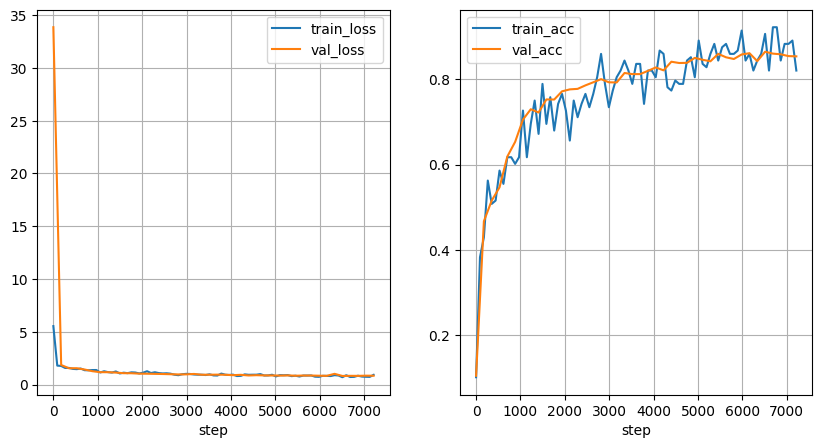

In [51]:
def plot_learning_curves(record_dict, sample_step=500):  # 画线要注意的是损失是不一定在零到1之间的
    # 将训练集记录字典转为 DataFrame，以 step 为索引，再以 sample_step 为步长采样（降采样）
    # .set_index("step")：将 step 列作为 DataFrame 索引，便于绘图时使用步数作为横轴
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]  # 将训练集记录字典转为 DataFrame，以 step 为索引，再以 sample_step 为步长采样（降采样）；.set_index("step")：将 step 列作为 DataFrame 索引，便于绘图时使用步数作为横轴；.iloc[::sample_step]：每隔 sample_step 行取一行（减少数据点，加快绘图）

    val_df = pd.DataFrame(record_dict["val"]).set_index("step")  # 将验证集记录转为 DataFrame（验证集记录较少，全部绘制无需采样）

    fig_num = len(train_df.columns)  # 子图数量等于指标列数（通常为 loss 和 acc 两列，即 fig_num=2）
    # plt.subplots(1, fig_num, ...)：创建 1 行 fig_num 列的子图网格
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))  # plt.subplots(1, fig_num, ...)：创建 1 行 fig_num 列的子图网格；figsize=(5*fig_num, 5)：每个子图宽 5 英寸，总宽随子图数量动态调整

    for idx, item in enumerate(train_df.columns):  # enumerate(train_df.columns) 返回 (列索引, 列名) 对，如 (0, 'loss'), (1, 'acc')
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")  # 在第 idx 个子图中绘制训练集曲线（横轴为步数，纵轴为当前指标值）
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")  # 在同一子图中绘制验证集曲线（与训练集对比）
        axs[idx].grid()    # 开启网格线，方便读取数值
        axs[idx].legend()      # 显示图例（区分训练和验证曲线）
        # 以下为自定义 x 轴刻度标签（已注释，可按需启用）
# axs[idx].set_xticks(range(0, train_df.index[-1], 5000))  # 说明性注释
        axs[idx].set_xlabel("step")    # 设置 x 轴标签为"step"（训练步数）

    plt.show()    # 在 notebook 中显示图表
sample_step=eval_step//2
plot_learning_curves(record, sample_step)  # 调用绘图函数，sample_step=10 表示每隔 10 步绘制一个训练集数据点


## 五、模型评估

训练完成后，加载最优检查点（best.ckpt）并在验证集上进行最终评估。

### 5.1 加载最优检查点并评估验证集性能

In [52]:
# ── 加载最优检查点并在验证集上评估模型性能 ──

# 从磁盘加载训练过程中保存的最优模型权重（state_dict）
# torch.load(path, map_location="cpu")：将保存的权重文件加载到 CPU 内存
# map_location="cpu"：即使模型保存时在 GPU 上，也强制加载到 CPU，避免设备不匹配错误
model.load_state_dict(torch.load(f"model_checkpoints/6_model/6_model_best.ckpt", map_location="cpu"))  # 从磁盘加载训练过程中保存的最优模型权重（state_dict）；torch.load(path, map_location="cpu")：将保存的权重文件加载到 CPU 内存；map_location="cpu"：即使模型保存时在 GPU 上，也强制加载到 CPU，避免设备不匹配错误；load_state_dict(...)：将加载的 state_dict（权重字典）赋值给模型的各参数


# 在验证集上计算最终的损失和准确率
loss, acc = evaluating(model, eval_dl, loss_fct)  # 在验证集上计算最终的损失和准确率；evaluating() 内部使用 @torch.no_grad() 关闭梯度计算

# 打印最优模型在验证集上的性能指标
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")  # 打印最优模型在验证集上的性能指标；{loss:.4f}：保留 4 位小数的格式化浮点数


loss:     0.8155
accuracy: 0.8644


## 六、预测与提交

使用训练好的最优模型对测试集进行预测，并将结果保存为 CSV 文件提交到 Kaggle。

### 6.1 对测试集进行推理预测

使用最优模型对所有测试集图片进行前向推理，得到每张图片的预测类别。

In [53]:
# ── 对测试集进行推理预测 ──

test_ds = Cifar10Dataset("test", transform=transforms_eval)  # 实例化测试集 Dataset（使用验证集相同的变换，即无随机增强）

# 创建测试集 DataLoader
# - shuffle=False：预测时不打乱顺序，保证预测结果与 test_df 行对应
test_dl = DataLoader(test_ds, batch_size=batch_size*2, shuffle=False, drop_last=False)  # 创建测试集 DataLoader；- shuffle=False：预测时不打乱顺序，保证预测结果与 test_df 行对应；- drop_last=False：保留最后一个不完整批次（确保所有测试样本都被预测）

preds_collect = []  # 存储所有批次的预测类别标签（字符串列表，如 ['frog', 'truck', ...]）

model.eval()  # 切换到评估模式（关闭 Dropout、BatchNorm 使用固定统计量）

for data, fake_label in tqdm(test_dl):  # 使用 tqdm 显示预测进度条，遍历每个测试批次
    # fake_label：测试集的占位标签（来自 sampleSubmission.csv，实际无意义）
    data = data.to(device=device)  # fake_label：测试集的占位标签（来自 sampleSubmission.csv，实际无意义）；将数据移到计算设备

    logits = model(data)    # 输出 logits，形状：(batch_size, num_classes)

    # logits.argmax(axis=-1)：沿类别维度取最大值索引，得到预测整数类别（形状：(batch_size,)）
    # .cpu().tolist()：移到 CPU 并转为 Python 整数列表
    preds = [test_ds.idx_to_label[idx] for idx in logits.argmax(axis=-1).cpu().tolist()]  # logits.argmax(axis=-1)：沿类别维度取最大值索引，得到预测整数类别（形状：(batch_size,)）；.cpu().tolist()：移到 CPU 并转为 Python 整数列表；idx_to_label[idx]：将整数索引转回类别名称字符串（如 6 -> 'frog'）

    preds_collect.extend(preds)  # 将当前批次的预测结果追加到汇总列表

test_df["class"] = preds_collect  # 将预测结果写回 test_df 的 'class' 列（替换原来的占位标签）

test_df.head()  # 展示前几行预测结果，验证预测是否正常


100%|██████████| 1172/1172 [03:06<00:00,  6.27it/s]


,filepath,class
0,data\cifar-10\test\1.png,deer
1,data\cifar-10\test\2.png,airplane
2,data\cifar-10\test\3.png,automobile
3,data\cifar-10\test\4.png,ship
4,data\cifar-10\test\5.png,airplane


### 6.2 保存预测结果（submission.csv）

将预测结果保存为标准 CSV 格式，满足 Kaggle 竞赛的提交要求。

In [54]:
# 将预测结果保存为 CSV 文件，用于提交到 Kaggle CIFAR-10 竞赛
# test_df.to_csv(path, index=False)：  # 说明性注释
# - path="submission.csv"：保存到当前工作目录下的 submission.csv 文件
# - index=False：不将 DataFrame 的行索引写入 CSV（Kaggle 提交不需要行号列）
test_df.to_csv("submission.csv", index=False)  # 将预测结果保存为 CSV 文件，用于提交到 Kaggle CIFAR-10 竞赛；- path="submission.csv"：保存到当前工作目录下的 submission.csv 文件；- index=False：不将 DataFrame 的行索引写入 CSV（Kaggle 提交不需要行号列）；保存后的 CSV 格式：filepath（图片路径）, class（预测类别名称）
